In [2]:
import scipy
import statsmodels.api as sm

In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import talib
from datetime import datetime
import matplotlib.pyplot as plt

In [4]:
# import data from ticker 

ydf = yf.download("NVDA",
                  start="2015-01-01",
                  end="2026-07-05",
                  progress=False)

In [5]:
print(f"Downloaded {len(ydf)} rows of data.")

Downloaded 2891 rows of data.


In [6]:
ydf

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2015-01-02,0.482423,0.486018,0.474754,0.482423,113680000
2015-01-05,0.474275,0.483861,0.472118,0.482423,197952000
2015-01-06,0.459896,0.475473,0.459416,0.474994,197764000
2015-01-07,0.458697,0.467325,0.457259,0.463251,321808000
2015-01-08,0.475952,0.478828,0.463730,0.463970,283780000
...,...,...,...,...,...
2026-06-26,192.529999,195.550003,191.220001,193.119995,179304100
2026-06-29,194.970001,196.179993,189.800003,193.850006,148835700


In [7]:
ydf.columns

MultiIndex([( 'Close', 'NVDA'),
            (  'High', 'NVDA'),
            (   'Low', 'NVDA'),
            (  'Open', 'NVDA'),
            ('Volume', 'NVDA')],
           names=['Price', 'Ticker'])

In [8]:
# Create column for the length of the candle body and daily price action (Total candle range)
ydf['Candle_Body'] = (ydf[('Close', 'NVDA')] - ydf[('Open', 'NVDA')]).abs()
ydf['Total price action'] = (ydf[('High', 'NVDA')] - ydf[('Low', 'NVDA')])

# Create a column to determine if Candle is bullish, bearish or a doji
doji = abs(ydf['Close', 'NVDA'] - ydf['Open', 'NVDA']) <= (0.10 * (ydf['High', 'NVDA'] - ydf['Close', 'NVDA']))
ydf['Bullish/Bearish'] = np.where(
    doji,
    'Doji',
    np.where((ydf['Close', 'NVDA'] > ydf['Open', 'NVDA']), 'Bullish', 'Bearish')
)

# Create column for candle body percentage by dividing the candle body by the total price action of the day
ydf['Body %'] = (ydf['Candle_Body'] / ydf['Total price action']) * 100

# Change total price action column to Candle_range 

ydf = ydf.rename(columns={'Total price action': 'Candle_Range'})

ydf

Price,Close,High,Low,Open,Volume,Candle_Body,Candle_Range,Bullish/Bearish,Body %
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,
Date,,,,,,,,,
2015-01-02,0.482423,0.486018,0.474754,0.482423,113680000,0.000000,0.011264,Doji,0.000000
2015-01-05,0.474275,0.483861,0.472118,0.482423,197952000,0.008148,0.011743,Bearish,69.387800
2015-01-06,0.459896,0.475473,0.459416,0.474994,197764000,0.015098,0.016057,Bearish,94.029920
2015-01-07,0.458697,0.467325,0.457259,0.463251,321808000,0.004553,0.010065,Bearish,45.237879
2015-01-08,0.475952,0.478828,0.463730,0.463970,283780000,0.011983,0.015098,Bullish,79.364899
...,...,...,...,...,...,...,...,...,...
2026-06-26,192.529999,195.550003,191.220001,193.119995,179304100,0.589996,4.330002,Bearish,13.625776
2026-06-29,194.970001,196.179993,189.800003,193.850006,148835700,1.119995,6.379990,Bullish,17.554811


In [9]:
ydf

Price,Close,High,Low,Open,Volume,Candle_Body,Candle_Range,Bullish/Bearish,Body %
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,
Date,,,,,,,,,
2015-01-02,0.482423,0.486018,0.474754,0.482423,113680000,0.000000,0.011264,Doji,0.000000
2015-01-05,0.474275,0.483861,0.472118,0.482423,197952000,0.008148,0.011743,Bearish,69.387800
2015-01-06,0.459896,0.475473,0.459416,0.474994,197764000,0.015098,0.016057,Bearish,94.029920
2015-01-07,0.458697,0.467325,0.457259,0.463251,321808000,0.004553,0.010065,Bearish,45.237879
2015-01-08,0.475952,0.478828,0.463730,0.463970,283780000,0.011983,0.015098,Bullish,79.364899
...,...,...,...,...,...,...,...,...,...
2026-06-26,192.529999,195.550003,191.220001,193.119995,179304100,0.589996,4.330002,Bearish,13.625776
2026-06-29,194.970001,196.179993,189.800003,193.850006,148835700,1.119995,6.379990,Bullish,17.554811


In [10]:
#Add 5, 10, 20, 50, and 200 day EMA Columns 

ydf['5_EMA'] = ydf['Close', 'NVDA'].ewm(span=5, adjust=False).mean()
ydf['10_EMA'] = ydf['Close', 'NVDA'].ewm(span=10, adjust=False).mean()
ydf['20_EMA'] = ydf['Close', 'NVDA'].ewm(span=20, adjust=False).mean()
ydf['50_EMA'] = ydf['Close', 'NVDA'].ewm(span=50, adjust=False).mean()
ydf['200_EMA'] = ydf['Close', 'NVDA'].ewm(span=200, adjust=False).mean()

ydf

Price,Close,High,Low,Open,Volume,Candle_Body,Candle_Range,Bullish/Bearish,Body %,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,,,,
Date,,,,,,,,,,,,,,
2015-01-02,0.482423,0.486018,0.474754,0.482423,113680000,0.000000,0.011264,Doji,0.000000,0.482423,0.482423,0.482423,0.482423,0.482423
2015-01-05,0.474275,0.483861,0.472118,0.482423,197952000,0.008148,0.011743,Bearish,69.387800,0.479707,0.480941,0.481647,0.482103,0.482342
2015-01-06,0.459896,0.475473,0.459416,0.474994,197764000,0.015098,0.016057,Bearish,94.029920,0.473103,0.477115,0.479575,0.481233,0.482119
2015-01-07,0.458697,0.467325,0.457259,0.463251,321808000,0.004553,0.010065,Bearish,45.237879,0.468301,0.473766,0.477587,0.480349,0.481886
2015-01-08,0.475952,0.478828,0.463730,0.463970,283780000,0.011983,0.015098,Bullish,79.364899,0.470852,0.474164,0.477431,0.480176,0.481826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,192.529999,195.550003,191.220001,193.119995,179304100,0.589996,4.330002,Bearish,13.625776,198.057808,201.806017,205.620792,205.334489,188.429772
2026-06-29,194.970001,196.179993,189.800003,193.850006,148835700,1.119995,6.379990,Bullish,17.554811,197.028539,200.563105,204.606431,204.928039,188.494849


In [11]:
import talib

In [12]:
ydf['RSI'] = talib.RSI(ydf['Close', 'NVDA'])
ydf

Price,Close,High,Low,Open,Volume,Candle_Body,Candle_Range,Bullish/Bearish,Body %,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,RSI
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,,,,,
Date,,,,,,,,,,,,,,,
2015-01-02,0.482423,0.486018,0.474754,0.482423,113680000,0.000000,0.011264,Doji,0.000000,0.482423,0.482423,0.482423,0.482423,0.482423,NaN
2015-01-05,0.474275,0.483861,0.472118,0.482423,197952000,0.008148,0.011743,Bearish,69.387800,0.479707,0.480941,0.481647,0.482103,0.482342,NaN
2015-01-06,0.459896,0.475473,0.459416,0.474994,197764000,0.015098,0.016057,Bearish,94.029920,0.473103,0.477115,0.479575,0.481233,0.482119,NaN
2015-01-07,0.458697,0.467325,0.457259,0.463251,321808000,0.004553,0.010065,Bearish,45.237879,0.468301,0.473766,0.477587,0.480349,0.481886,NaN
2015-01-08,0.475952,0.478828,0.463730,0.463970,283780000,0.011983,0.015098,Bullish,79.364899,0.470852,0.474164,0.477431,0.480176,0.481826,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,192.529999,195.550003,191.220001,193.119995,179304100,0.589996,4.330002,Bearish,13.625776,198.057808,201.806017,205.620792,205.334489,188.429772,37.574160
2026-06-29,194.970001,196.179993,189.800003,193.850006,148835700,1.119995,6.379990,Bullish,17.554811,197.028539,200.563105,204.606431,204.928039,188.494849,40.158152


In [13]:
import vectorbt as vbt

In [29]:
#Calculate the upper wick by subtracking the high from either the open or close. Use max function and axis=1 to choose the option closest to the upperwick
ydf['Upper_wick'] = abs(ydf['High', 'NVDA'] - ydf[[('Open', 'NVDA'), ('Close', 'NVDA')]].max(axis=1))
# Caculate the same for the lower wick using the min function with axis=1 so it chooses the value closest to the lower wick between the open and close
ydf['Lower_wick'] = abs(ydf['Low', 'NVDA'] - ydf[[('Open', 'NVDA'), ('Close', 'NVDA')]].min(axis=1))

# Calculate wick percentage by dividing the absolute value of the upper or lower wick by the candle ranage (total candle length)
ydf[('Upper_wick_percentage', "")] = abs(ydf[('Upper_wick', "")] / ydf[('Candle_Range', "")]) * 100
ydf[('Lower_wick_percentage', "")] = abs(ydf[('Lower_wick', "")] / ydf[('Candle_Range', "")]) * 100

# Calculate Wick to body ratio by dividing the sum of the wicks by the candle body
ydf[('Wick_to_body_ratio', "")] = (ydf[('Lower_wick', "")] + ydf[('Upper_wick', "")]) / ydf[('Candle_Body', "")]

# Calsulate the gap size 
ydf[('gap_size', "")] = ydf[('Open', 'NVDA')] - ydf[('Close', 'NVDA')].shift(1)
# Calculate gap percentage 
ydf[('gap_percentage', "")] = (ydf[('gap_size', "")] / ydf[('Close', 'NVDA')].shift(1)) * 100

# Caluclate if an EMA was touched by price action
ydf[('5EMA_touched', "")] = np.where((ydf['5_EMA'] >= ydf['Low', 'NVDA']) & (ydf['5_EMA'] <= ydf['High', 'NVDA']), 'True', 'False')
ydf[('10EMA_touched', "")] = np.where((ydf['10_EMA'] >= ydf['Low', 'NVDA']) & (ydf['10_EMA'] <= ydf['High', 'NVDA']), 'True', 'False')
ydf[('20EMA_touched', "")] = np.where((ydf['20_EMA'] >= ydf['Low', 'NVDA']) & (ydf['20_EMA'] <= ydf['High', 'NVDA']), 'True', 'False')
ydf[('50EMA_touched', "")] = np.where((ydf['50_EMA'] >= ydf['Low', 'NVDA']) & (ydf['50_EMA'] <= ydf['High', 'NVDA']), 'True', 'False')
ydf[('200EMA_touched', "")] = np.where((ydf['200_EMA'] >= ydf['Low', 'NVDA']) & (ydf['200_EMA'] <= ydf['High', 'NVDA']), 'True', 'False')
ydf

Price,Close,High,Low,Open,Volume,Candle_Body,Candle_Range,Bullish/Bearish,Body %,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,RSI,Upper_wick,Lower_wick,Upper_wick_percentage,Lower_wick_percentage,Wick_to_body_ratio,gap_size,gap_percentage,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,confirmed_trend
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,,,,,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0.482423,0.486018,0.474754,0.482423,113680000,0.000000,0.011264,Doji,0.000000,0.482423,0.482423,0.482423,0.482423,0.482423,NaN,0.003595,0.007669,31.915002,68.084998,inf,NaN,NaN,True,True,True,True,True,0
2015-01-05,0.474275,0.483861,0.472118,0.482423,197952000,0.008148,0.011743,Bearish,69.387800,0.479707,0.480941,0.481647,0.482103,0.482342,NaN,0.001438,0.002157,12.244977,18.367223,0.441176,-1.677890e-08,-0.000003,True,True,True,True,True,0
2015-01-06,0.459896,0.475473,0.459416,0.474994,197764000,0.015098,0.016057,Bearish,94.029920,0.473103,0.477115,0.479575,0.481233,0.482119,NaN,0.000479,0.000479,2.985040,2.985040,0.063491,7.190040e-04,0.151601,True,False,False,False,False,0
2015-01-07,0.458697,0.467325,0.457259,0.463251,321808000,0.004553,0.010065,Bearish,45.237879,0.468301,0.473766,0.477587,0.480349,0.481886,NaN,0.004074,0.001438,40.476326,14.285795,1.210537,3.355113e-03,0.729538,False,False,False,False,False,0
2015-01-08,0.475952,0.478828,0.463730,0.463970,283780000,0.011983,0.015098,Bullish,79.364899,0.470852,0.474164,0.477431,0.480176,0.481826,NaN,0.002876,0.000240,19.047727,1.587374,0.260003,5.272450e-03,1.149440,True,True,True,False,False,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,192.529999,195.550003,191.220001,193.119995,179304100,0.589996,4.330002,Bearish,13.625776,198.057808,201.806017,205.620792,205.334489,188.429772,37.574160,2.430008,1.309998,56.120252,30.253972,6.339032,-2.620010e+00,-1.338516,False,False,False,False,False,0
2026-06-29,194.970001,196.179993,189.800003,193.850006,148835700,1.119995,6.379990,Bullish,17.554811,197.028539,200.563105,204.606431,204.928039,188.494849,40.158152,1.209991,4.050003,18.965414,63.479775,4.696444,1.320007e+00,0.685611,False,False,False,False,False,-1


**Now let's create some features to help us determine market trend.**|

In [30]:
pd.set_option('display.max_columns', None)

In [97]:
# We'll start by determining peaks and valleys  
close = ydf['Close', 'NVDA']

# True trend structure is ALWAYs determine 
peak = (
    (ydf['Close', 'NVDA'] > ydf['Close', 'NVDA'].shift(1)) &
     (ydf['Close', 'NVDA'] > ydf['Close', 'NVDA'].shift(-1))
)
valley = (
    (ydf['Close', 'NVDA'] < ydf['Close', 'NVDA'].shift(1)) &
    (ydf['Close', 'NVDA'] < ydf['Close', 'NVDA'].shift(-1))
)

#separate peak and valley closing prices

peak_closes = close.where(peak)
valley_closes = close.where(valley)

# Separate previous peak and close prices
# I 100% looked this part up on google
prev_peak_cl = peak_closes.dropna().shift(1).reindex(close.index).ffill() 
prev_valley_cl = valley_closes.dropna().shift(1).reindex(close.index).ffill() 


#current peak/valley closes forward fill
current_peak = peak_closes.ffill()
current_valley = valley_closes.ffill()

# Confirms current peaks and valleys based on previous after proper structure

HH = (current_peak > prev_peak_cl) & peak
HL = (current_peak < prev_peak_cl) & peak
LH = (current_valley > prev_valley_cl) & valley
LL = (current_valley < prev_valley_cl) & valley

# Now let's set parameters on how we want to search for higher highs, higher lows, lower highs and lower low

Uptrend = (HH.rolling(15).sum() >= 2) & (HL.rolling(15).sum() >= 1)
Downtrend = (LH.rolling(15).sum() >= 2) & (LL.rolling(15).sum() >= 1)

# Now let's bring it all together to determine uptrend and downtrend 

ydf[('confirmed_trend', "")] = np.select( [Uptrend, Downtrend], [1, -1],default=0)

ydf[('confirmed_trend', "")].value_counts()

(confirmed_trend, )
 1    1682
 0     754
-1     455
Name: count, dtype: int64

In [98]:
ydf

Price,Close,High,Low,Open,Volume,Candle_Body,Candle_Range,Bullish/Bearish,Body %,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,RSI,Upper_wick,Lower_wick,Upper_wick_percentage,Lower_wick_percentage,Wick_to_body_ratio,gap_size,gap_percentage,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,confirmed_trend,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Harami,Harami_cross
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0.482423,0.486018,0.474754,0.482423,113680000,0.000000,0.011264,Doji,0.000000,0.482423,0.482423,0.482423,0.482423,0.482423,NaN,0.003595,0.007669,31.915002,68.084998,inf,NaN,NaN,True,True,True,True,True,0,divergence,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,1120.554147,0,0
2015-01-05,0.474275,0.483861,0.472118,0.482423,197952000,0.008148,0.011743,Bearish,69.387800,0.479707,0.480941,0.481647,0.482103,0.482342,NaN,0.001438,0.002157,12.244977,18.367223,0.441176,-1.677890e-08,-0.000003,True,True,True,True,True,0,Bearish,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,1117.675359,0,0
2015-01-06,0.459896,0.475473,0.459416,0.474994,197764000,0.015098,0.016057,Bearish,94.029920,0.473103,0.477115,0.479575,0.481233,0.482119,NaN,0.000479,0.000479,2.985040,2.985040,0.063491,7.190040e-04,0.151601,True,False,False,False,False,0,Bearish,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,1171.855306,0,0
2015-01-07,0.458697,0.467325,0.457259,0.463251,321808000,0.004553,0.010065,Bearish,45.237879,0.468301,0.473766,0.477587,0.480349,0.481886,NaN,0.004074,0.001438,40.476326,14.285795,1.210537,3.355113e-03,0.729538,False,False,False,False,False,0,Bearish,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,1200.161195,0,0
2015-01-08,0.475952,0.478828,0.463730,0.463970,283780000,0.011983,0.015098,Bullish,79.364899,0.470852,0.474164,0.477431,0.480176,0.481826,NaN,0.002876,0.000240,19.047727,1.587374,0.260003,5.272450e-03,1.149440,True,True,True,False,False,0,Bearish,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,1132.969375,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,192.529999,195.550003,191.220001,193.119995,179304100,0.589996,4.330002,Bearish,13.625776,198.057808,201.806017,205.620792,205.334489,188.429772,37.574160,2.430008,1.309998,56.120252,30.253972,6.339032,-2.620010e+00,-1.338516,False,False,False,False,False,0,divergence,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2026-06-29,194.970001,196.179993,189.800003,193.850006,148835700,1.119995,6.379990,Bullish,17.554811,197.028539,200.563105,204.606431,204.928039,188.494849,40.158152,1.209991,4.050003,18.965414,63.479775,4.696444,1.320007e+00,0.685611,False,False,False,False,False,0,divergence,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [99]:
# Now Let's work with out EMA's and see if we can determine a stock's direction based on how they stack out

EMA_Bullish = (
   (ydf[('5_EMA', "")] > ydf[('10_EMA', "")]) &
   (ydf[('10_EMA', "")] > ydf[('20_EMA', "")]) &
   (ydf[('20_EMA', "")] > ydf[('50_EMA', "")]) & 
    (ydf[('50_EMA', "")] > ydf[('200_EMA', "")])
)

EMA_Bearish = (
    (ydf['5_EMA', ""] < ydf['10_EMA', ""]) &
   (ydf['10_EMA', ""] < ydf['20_EMA', ""]) &
   (ydf['20_EMA', ""] < ydf['50_EMA', ""]) & 
   (ydf['50_EMA', ""] < ydf['200_EMA', ""])
)

#Combine everything into one column to show bullish, bearish, divergence 
ydf['EMA_Alignment', ""] = 'divergence' 
ydf.loc[EMA_Bullish, ('EMA_Alignment', "")] = 'Bullish'
ydf.loc[EMA_Bearish, ('EMA_Alignment', "")] = 'Bearish'

ydf


Price,Close,High,Low,Open,Volume,Candle_Body,Candle_Range,Bullish/Bearish,Body %,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,RSI,Upper_wick,Lower_wick,Upper_wick_percentage,Lower_wick_percentage,Wick_to_body_ratio,gap_size,gap_percentage,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,confirmed_trend,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Harami,Harami_cross
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0.482423,0.486018,0.474754,0.482423,113680000,0.000000,0.011264,Doji,0.000000,0.482423,0.482423,0.482423,0.482423,0.482423,NaN,0.003595,0.007669,31.915002,68.084998,inf,NaN,NaN,True,True,True,True,True,0,divergence,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,1120.554147,0,0
2015-01-05,0.474275,0.483861,0.472118,0.482423,197952000,0.008148,0.011743,Bearish,69.387800,0.479707,0.480941,0.481647,0.482103,0.482342,NaN,0.001438,0.002157,12.244977,18.367223,0.441176,-1.677890e-08,-0.000003,True,True,True,True,True,0,Bearish,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,1117.675359,0,0
2015-01-06,0.459896,0.475473,0.459416,0.474994,197764000,0.015098,0.016057,Bearish,94.029920,0.473103,0.477115,0.479575,0.481233,0.482119,NaN,0.000479,0.000479,2.985040,2.985040,0.063491,7.190040e-04,0.151601,True,False,False,False,False,0,Bearish,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,1171.855306,0,0
2015-01-07,0.458697,0.467325,0.457259,0.463251,321808000,0.004553,0.010065,Bearish,45.237879,0.468301,0.473766,0.477587,0.480349,0.481886,NaN,0.004074,0.001438,40.476326,14.285795,1.210537,3.355113e-03,0.729538,False,False,False,False,False,0,Bearish,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,1200.161195,0,0
2015-01-08,0.475952,0.478828,0.463730,0.463970,283780000,0.011983,0.015098,Bullish,79.364899,0.470852,0.474164,0.477431,0.480176,0.481826,NaN,0.002876,0.000240,19.047727,1.587374,0.260003,5.272450e-03,1.149440,True,True,True,False,False,0,Bearish,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,1132.969375,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,192.529999,195.550003,191.220001,193.119995,179304100,0.589996,4.330002,Bearish,13.625776,198.057808,201.806017,205.620792,205.334489,188.429772,37.574160,2.430008,1.309998,56.120252,30.253972,6.339032,-2.620010e+00,-1.338516,False,False,False,False,False,0,divergence,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2026-06-29,194.970001,196.179993,189.800003,193.850006,148835700,1.119995,6.379990,Bullish,17.554811,197.028539,200.563105,204.606431,204.928039,188.494849,40.158152,1.209991,4.050003,18.965414,63.479775,4.696444,1.320007e+00,0.685611,False,False,False,False,False,0,divergence,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


**Now let's create a touch count features for the 5, 10, and 20EMAs**

In [100]:
# Create a touhced variable by calling only the column strings that = True 

touched = ydf[("5EMA_touched", "")] == 'True'

# Create a cumulative total of touches 
touched_group = touched.cumsum()

# Create a not touched variable 
not_touched = ydf[("5EMA_touched", "")] == 'False'

# Now group them together to allow for cumulative count of days without a touch 
ydf[('5EMA_days_since_touch', "")] = not_touched.groupby(touched_group).cumsum()

# Now let's do the same with the 10 
touched10 = ydf[("10EMA_touched", "")] == 'True'

touched_group10 = touched10.cumsum()

not_touched10 = ydf[("10EMA_touched", "")] == 'False'

ydf[('10EMA_days_since_touch', "")] = not_touched10.groupby(touched_group10).cumsum()

# And now the 20

touched20 = ydf[("20EMA_touched", "")] == 'True'

touched_group20 = touched20.cumsum()

not_touched20 = ydf[("20EMA_touched", "")] == 'False'

ydf[('20EMA_days_since_touch', "")] = not_touched20.groupby(touched_group20).cumsum()

ydf

Price,Close,High,Low,Open,Volume,Candle_Body,Candle_Range,Bullish/Bearish,Body %,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,RSI,Upper_wick,Lower_wick,Upper_wick_percentage,Lower_wick_percentage,Wick_to_body_ratio,gap_size,gap_percentage,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,confirmed_trend,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Harami,Harami_cross
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0.482423,0.486018,0.474754,0.482423,113680000,0.000000,0.011264,Doji,0.000000,0.482423,0.482423,0.482423,0.482423,0.482423,NaN,0.003595,0.007669,31.915002,68.084998,inf,NaN,NaN,True,True,True,True,True,0,divergence,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,1120.554147,0,0
2015-01-05,0.474275,0.483861,0.472118,0.482423,197952000,0.008148,0.011743,Bearish,69.387800,0.479707,0.480941,0.481647,0.482103,0.482342,NaN,0.001438,0.002157,12.244977,18.367223,0.441176,-1.677890e-08,-0.000003,True,True,True,True,True,0,Bearish,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,1117.675359,0,0
2015-01-06,0.459896,0.475473,0.459416,0.474994,197764000,0.015098,0.016057,Bearish,94.029920,0.473103,0.477115,0.479575,0.481233,0.482119,NaN,0.000479,0.000479,2.985040,2.985040,0.063491,7.190040e-04,0.151601,True,False,False,False,False,0,Bearish,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,1171.855306,0,0
2015-01-07,0.458697,0.467325,0.457259,0.463251,321808000,0.004553,0.010065,Bearish,45.237879,0.468301,0.473766,0.477587,0.480349,0.481886,NaN,0.004074,0.001438,40.476326,14.285795,1.210537,3.355113e-03,0.729538,False,False,False,False,False,0,Bearish,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,1200.161195,0,0
2015-01-08,0.475952,0.478828,0.463730,0.463970,283780000,0.011983,0.015098,Bullish,79.364899,0.470852,0.474164,0.477431,0.480176,0.481826,NaN,0.002876,0.000240,19.047727,1.587374,0.260003,5.272450e-03,1.149440,True,True,True,False,False,0,Bearish,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,1132.969375,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,192.529999,195.550003,191.220001,193.119995,179304100,0.589996,4.330002,Bearish,13.625776,198.057808,201.806017,205.620792,205.334489,188.429772,37.574160,2.430008,1.309998,56.120252,30.253972,6.339032,-2.620010e+00,-1.338516,False,False,False,False,False,0,divergence,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2026-06-29,194.970001,196.179993,189.800003,193.850006,148835700,1.119995,6.379990,Bullish,17.554811,197.028539,200.563105,204.606431,204.928039,188.494849,40.158152,1.209991,4.050003,18.965414,63.479775,4.696444,1.320007e+00,0.685611,False,False,False,False,False,0,divergence,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [101]:
ydf['EMA_Alignment'].value_counts()

EMA_Alignment
Bullish       1436
divergence    1275
Bearish        180
Name: count, dtype: int64

**Time for some Math on returns!** We need to put the final touches on this feature engineering which has felt rigorous. We need now need to create the most important and easiest features. OUR RETURNS FEATURE! The fun part. The money! Or at least the percentage gain. I will be be looking at short term and long term so we will have a lot of different investment strategies as options. These will be a bit raw becase the CPI library in Python is not up to date and could not be updated. Stopped at 1997 but I can do some raw CPI conversions and if I have extra time, I do not since I am already behind, I will. 

In [102]:
ydf['5_day_return'] = ((ydf['Close', 'NVDA'].shift(-5) - ydf['Close', 'NVDA']) / ydf['Close', 'NVDA']) * 100
ydf['10_day_return'] = ((ydf['Close', 'NVDA'].shift(-10) - ydf['Close', 'NVDA']) / ydf['Close', 'NVDA']) * 100
ydf['15_day_return'] = ((ydf['Close', 'NVDA'].shift(-15) - ydf['Close', 'NVDA']) / ydf['Close', 'NVDA']) * 100
ydf['22_day_return'] = ((ydf['Close', 'NVDA'].shift(-22) - ydf['Close', 'NVDA']) / ydf['Close', 'NVDA']) * 100
ydf['6_month_return'] = ((ydf['Close', 'NVDA'].shift(-125) - ydf['Close', 'NVDA']) / ydf['Close', 'NVDA']) * 100
ydf['1_year_return'] = ((ydf['Close', 'NVDA'].shift(-251) - ydf['Close', 'NVDA']) / ydf['Close', 'NVDA']) * 100
ydf['5_year_return'] = ((ydf['Close', 'NVDA'].shift(-1255) - ydf['Close', 'NVDA']) / ydf['Close', 'NVDA']) * 100
ydf

Price,Close,High,Low,Open,Volume,Candle_Body,Candle_Range,Bullish/Bearish,Body %,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,RSI,Upper_wick,Lower_wick,Upper_wick_percentage,Lower_wick_percentage,Wick_to_body_ratio,gap_size,gap_percentage,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,confirmed_trend,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Harami,Harami_cross
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0.482423,0.486018,0.474754,0.482423,113680000,0.000000,0.011264,Doji,0.000000,0.482423,0.482423,0.482423,0.482423,0.482423,NaN,0.003595,0.007669,31.915002,68.084998,inf,NaN,NaN,True,True,True,True,True,0,divergence,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,1120.554147,0,0
2015-01-05,0.474275,0.483861,0.472118,0.482423,197952000,0.008148,0.011743,Bearish,69.387800,0.479707,0.480941,0.481647,0.482103,0.482342,NaN,0.001438,0.002157,12.244977,18.367223,0.441176,-1.677890e-08,-0.000003,True,True,True,True,True,0,Bearish,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,1117.675359,0,0
2015-01-06,0.459896,0.475473,0.459416,0.474994,197764000,0.015098,0.016057,Bearish,94.029920,0.473103,0.477115,0.479575,0.481233,0.482119,NaN,0.000479,0.000479,2.985040,2.985040,0.063491,7.190040e-04,0.151601,True,False,False,False,False,0,Bearish,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,1171.855306,0,0
2015-01-07,0.458697,0.467325,0.457259,0.463251,321808000,0.004553,0.010065,Bearish,45.237879,0.468301,0.473766,0.477587,0.480349,0.481886,NaN,0.004074,0.001438,40.476326,14.285795,1.210537,3.355113e-03,0.729538,False,False,False,False,False,0,Bearish,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,1200.161195,0,0
2015-01-08,0.475952,0.478828,0.463730,0.463970,283780000,0.011983,0.015098,Bullish,79.364899,0.470852,0.474164,0.477431,0.480176,0.481826,NaN,0.002876,0.000240,19.047727,1.587374,0.260003,5.272450e-03,1.149440,True,True,True,False,False,0,Bearish,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,1132.969375,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,192.529999,195.550003,191.220001,193.119995,179304100,0.589996,4.330002,Bearish,13.625776,198.057808,201.806017,205.620792,205.334489,188.429772,37.574160,2.430008,1.309998,56.120252,30.253972,6.339032,-2.620010e+00,-1.338516,False,False,False,False,False,0,divergence,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2026-06-29,194.970001,196.179993,189.800003,193.850006,148835700,1.119995,6.379990,Bullish,17.554811,197.028539,200.563105,204.606431,204.928039,188.494849,40.158152,1.209991,4.050003,18.965414,63.479775,4.696444,1.320007e+00,0.685611,False,False,False,False,False,0,divergence,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


Finally let's add these candlestick patterns. It's been a long road and there have undoubtedly been times I did not think I would make it. To be honest I still have not made it. I will keep working until I do make it. Still have a long way to go but once we get the statistically modeling done AFTER THIS, then I will feel like I am almost home. I like Haramis and Harami Crosses because they are easily identifiable and I have always found them dependable. 

In [103]:
# We can use Talib to find whatever candlestick patterns we want to work with. 

ydf[('Harami', "")] = talib.CDLHARAMI(
    ydf[('Open', 'NVDA')],
    ydf[('High', 'NVDA')],
    ydf[('Low', 'NVDA')], 
    ydf[('Close', 'NVDA')]
)

ydf[('Harami_cross', "")] = talib.CDLHARAMICROSS(
     ydf[('Open', 'NVDA')],
    ydf[('High', 'NVDA')],
    ydf[('Low', 'NVDA')], 
    ydf[('Close', 'NVDA')]
)
    
ydf['Harami'].value_counts()

Harami
 0      2671
 100     114
-100     106
Name: count, dtype: int64

In [104]:
ydf['Harami_cross'].value_counts()

Harami_cross
 0      2824
 100      38
-100      29
Name: count, dtype: int64

So this is fun. Based on this count there are been 115 Bullish Harami patterns within NVDA and 107 Bearish Hamari Patterns. So 115 times in its history NVDA has given a signal that price has "hit a bottom" and the trend was about to reverse to the upside and 107 times NVDA gave a signal that the price had "hit a top" and the trend was about to the downside. Now let's plot that this out and see what we get. 

In [105]:
Bullish_Harami = ydf[ydf[('Harami', "")] == 100]
Bearish_Harami = ydf[ydf[('Harami', "")] == -100]
Bullish_har_cross = ydf[ydf[('Harami_cross', "")] == 100]
Bearish_har_cross = ydf[ydf[('Harami_cross', "")] == -100]

In [106]:
Bullish_Harami

Price,Close,High,Low,Open,Volume,Candle_Body,Candle_Range,Bullish/Bearish,Body %,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,RSI,Upper_wick,Lower_wick,Upper_wick_percentage,Lower_wick_percentage,Wick_to_body_ratio,gap_size,gap_percentage,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,confirmed_trend,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Harami,Harami_cross
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-02-02,0.470201,0.472118,0.453904,0.463011,259604000,0.007190,0.018214,Bullish,39.473659,0.470470,0.473951,0.476144,0.478499,0.481097,45.694845,0.001917,0.009107,10.526341,50.000000,1.533335,0.002876,0.624990,True,False,False,False,False,0,Bearish,0,1,4,3.873593,14.067292,14.148358,16.962424,2.545978,51.814349,1210.964559,100,0
2015-04-01,0.505451,0.507135,0.496791,0.505451,330768000,0.000000,0.010345,Doji,0.000000,0.511317,0.520533,0.527713,0.520766,0.497386,39.383982,0.001684,0.008661,16.279005,83.720995,inf,0.001924,0.382195,False,False,False,False,True,1,divergence,1,7,6,7.234672,7.044226,5.759130,7.615377,13.850423,72.363022,1165.883827,100,100
2015-04-22,0.536726,0.537448,0.525660,0.533839,207420000,0.002887,0.011788,Bullish,24.489468,0.535042,0.534650,0.533305,0.526622,0.502158,52.698768,0.000722,0.008180,6.122489,69.388043,3.083388,0.003127,0.589262,True,True,True,True,False,0,Bullish,0,0,0,-0.761974,-0.941279,-6.095912,-6.066560,25.756518,66.055169,1265.720691,100,0
2015-05-06,0.531674,0.537929,0.524697,0.532877,316484000,0.001203,0.013232,Bearish,9.090673,0.535119,0.535542,0.534814,0.529582,0.505333,48.405982,0.005052,0.006977,38.182039,52.727288,10.000286,0.002887,0.544713,True,True,True,True,False,0,divergence,0,0,0,-5.203613,-4.355678,0.644708,-1.128160,31.014282,59.860765,1267.376931,100,0
2015-06-09,0.528334,0.532201,0.525192,0.526159,256888000,0.002175,0.007009,Bullish,31.034908,0.529727,0.528005,0.525325,0.524376,0.508168,51.950795,0.003867,0.000967,55.172074,13.793018,2.222178,0.000483,0.091909,True,True,True,False,False,1,Bullish,0,0,0,-2.424475,-2.927657,-8.005477,-9.652305,55.629948,114.974671,1551.431157,100,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-18,173.927856,175.935402,171.610691,174.317381,176096000,0.389524,4.324712,Bearish,9.006942,175.148957,177.308415,179.937654,182.221024,164.025093,41.541247,1.618022,2.317166,37.413398,53.579660,10.102547,3.585615,2.100145,True,False,False,False,False,1,divergence,0,4,6,9.411972,8.028031,6.201910,6.144482,19.963529,NaN,NaN,100,100
2026-01-07,188.879623,191.136865,186.332727,188.340288,153543200,0.539335,4.804138,Bullish,11.226477,187.879624,186.802403,185.232534,184.163015,166.645460,56.150493,2.257241,2.007561,46.985357,41.788166,7.907514,1.328371,0.710313,True,True,False,False,False,1,Bullish,0,0,11,-3.156899,-2.257947,1.797896,0.491775,NaN,NaN,NaN,100,0


In [107]:
import mplfinance as mpf

We have run into a snag. This is a multilevel index which is not mpf friend. Do I first must do something to change the dataframe into a friendlier format. 

In [108]:
# First let's make a copy of our dataframe in case something goes wrong 
ydf_single = ydf.copy()
# Then we take only the Price level of our index
ydf_single.columns = ydf_single.columns.get_level_values("Price")
#Then we reset the index
ydf_single = ydf_single.reset_index()
# To get our row level index back to date we set the index as date
ydf_single.set_index('Date', inplace=True)
# and in case anyone wonders what stock we are working on we can set the ticker as a column 
ydf_single["Ticker"] = "NVDA"

In [109]:
nvdf = ydf_single

In [110]:
nvdf

Price,Close,High,Low,Open,Volume,Candle_Body,Candle_Range,Bullish/Bearish,Body %,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,RSI,Upper_wick,Lower_wick,Upper_wick_percentage,Lower_wick_percentage,Wick_to_body_ratio,gap_size,gap_percentage,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,confirmed_trend,EMA_Alignment,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Harami,Harami_cross,Ticker
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,0.482423,0.486018,0.474754,0.482423,113680000,0.000000,0.011264,Doji,0.000000,0.482423,0.482423,0.482423,0.482423,0.482423,NaN,0.003595,0.007669,31.915002,68.084998,inf,NaN,NaN,True,True,True,True,True,0,divergence,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,1120.554147,0,0,NVDA
2015-01-05,0.474275,0.483861,0.472118,0.482423,197952000,0.008148,0.011743,Bearish,69.387800,0.479707,0.480941,0.481647,0.482103,0.482342,NaN,0.001438,0.002157,12.244977,18.367223,0.441176,-1.677890e-08,-0.000003,True,True,True,True,True,0,Bearish,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,1117.675359,0,0,NVDA
2015-01-06,0.459896,0.475473,0.459416,0.474994,197764000,0.015098,0.016057,Bearish,94.029920,0.473103,0.477115,0.479575,0.481233,0.482119,NaN,0.000479,0.000479,2.985040,2.985040,0.063491,7.190040e-04,0.151601,True,False,False,False,False,0,Bearish,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,1171.855306,0,0,NVDA
2015-01-07,0.458697,0.467325,0.457259,0.463251,321808000,0.004553,0.010065,Bearish,45.237879,0.468301,0.473766,0.477587,0.480349,0.481886,NaN,0.004074,0.001438,40.476326,14.285795,1.210537,3.355113e-03,0.729538,False,False,False,False,False,0,Bearish,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,1200.161195,0,0,NVDA
2015-01-08,0.475952,0.478828,0.463730,0.463970,283780000,0.011983,0.015098,Bullish,79.364899,0.470852,0.474164,0.477431,0.480176,0.481826,NaN,0.002876,0.000240,19.047727,1.587374,0.260003,5.272450e-03,1.149440,True,True,True,False,False,0,Bearish,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,1132.969375,0,0,NVDA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,192.529999,195.550003,191.220001,193.119995,179304100,0.589996,4.330002,Bearish,13.625776,198.057808,201.806017,205.620792,205.334489,188.429772,37.574160,2.430008,1.309998,56.120252,30.253972,6.339032,-2.620010e+00,-1.338516,False,False,False,False,False,0,divergence,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NVDA
2026-06-29,194.970001,196.179993,189.800003,193.850006,148835700,1.119995,6.379990,Bullish,17.554811,197.028539,200.563105,204.606431,204.928039,188.494849,40.158152,1.209991,4.050003,18.965414,63.479775,4.696444,1.320007e+00,0.685611,False,False,False,False,False,0,divergence,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NVDA
2026-06-30,200.089996,200.630005,195.110001,197.240005,166476700,2.849991,5.520004,Bullish,51.630229,198.049025,200.477085,204.176294,204.738312,188.610223,45.276875,0.540009,2.130005,9.782756,38.587015,0.936850,2.270004e+00,1.164284,True,True,False,False,False,0,divergence,0,0,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NVDA


**Excellent!** That fixed the problem! YAY! 

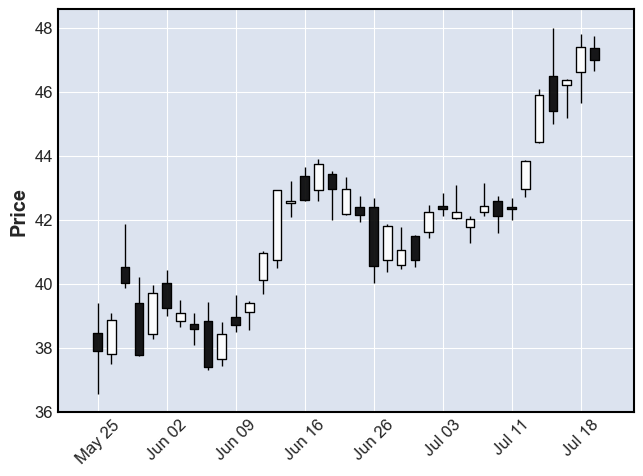

In [111]:
mpf.plot(nvdf["2023-05-25": "2023-07-19"],
         type="candle")

Thats cool! But it looks a little boring. Let's see if we can give it something to make it pop more. 

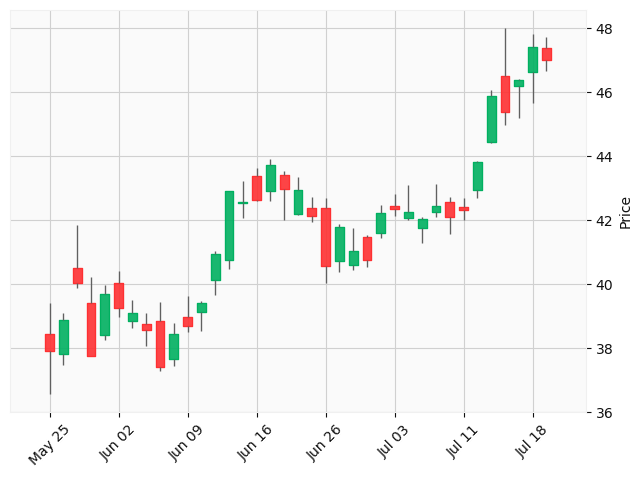

In [112]:
mpf.plot(nvdf["2023-05-25": "2023-07-19"],
         type="candle", style='yahoo')

Looks cool but let's add some EMAs too it to see how they work with. We may need to convert them to a friendier format for MPF (Matplotlib Finance). 

In [113]:
# Convert the EMAs to a format that MPF will understand but first we will need to make sure the number of rows match down to the date. 

plot_df = nvdf["2023-05-25": "2023-07-19"]

ap_emas = [
    mpf.make_addplot(plot_df['5_EMA'], color='pink', width=1.5),
    mpf.make_addplot(plot_df['10_EMA'], color='orange', width=2),
    mpf.make_addplot(plot_df['20_EMA'], color='blue', width=2.5),
    mpf.make_addplot(plot_df['50_EMA'], color='yellow', width=3)
]

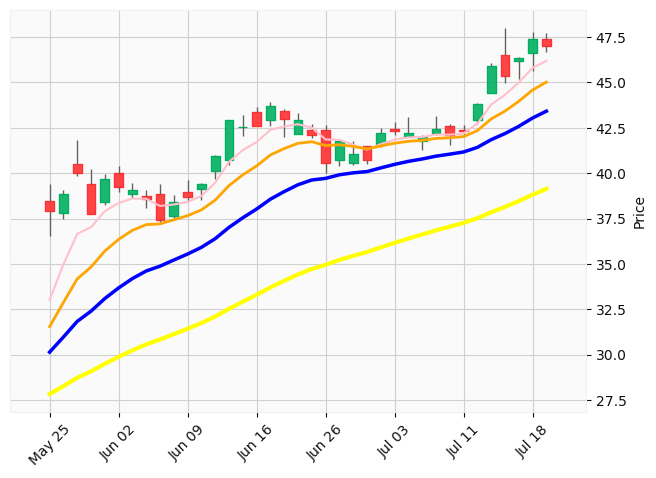

In [114]:
mpf.plot(nvdf["2023-05-25": "2023-07-19"], type="candle", style='yahoo', addplot=ap_emas)

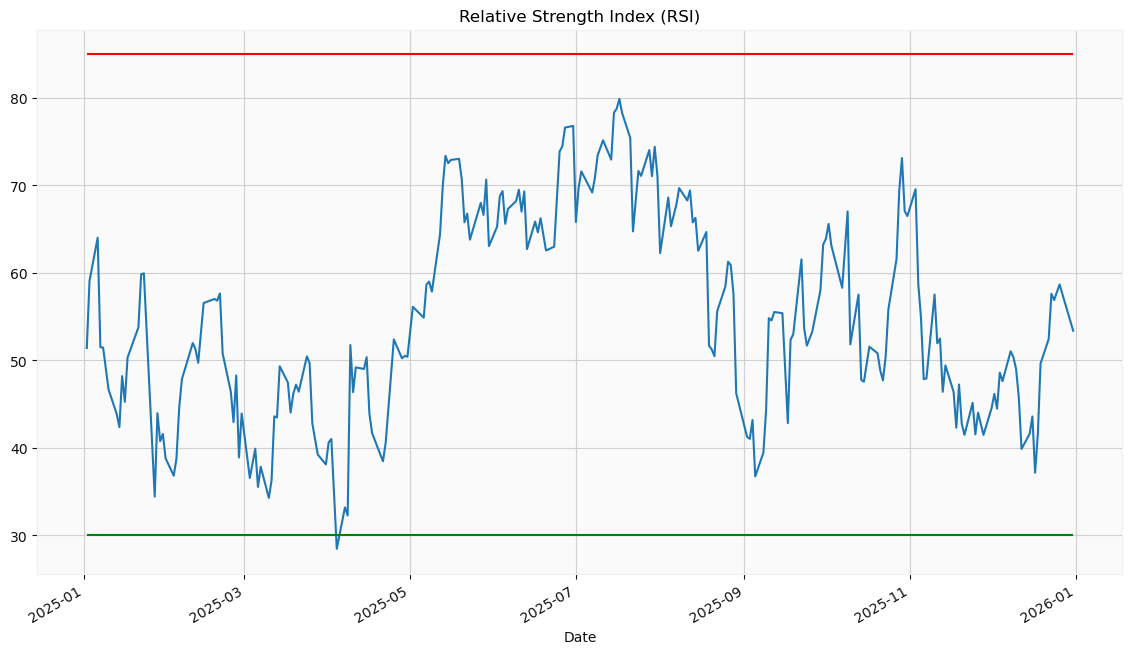

In [123]:

window = nvdf["2025-01-01": "2025-12-31"]

fig, ax = plt.subplots(figsize=(14, 8))
window['RSI'].plot(ax=ax,
                 title='Relative Strength Index (RSI)')

ax.hlines(y=30,
          xmin=window.index.min(),
          xmax=window.index.max(),
          color='green')
ax.hlines(y=85,
          xmin=window.index.min(),
          xmax=window.index.max(),
          color='red')

plt.show()


In [116]:
nvdf.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Candle_Body', 'Candle_Range',
       'Bullish/Bearish', 'Body %', '5_EMA', '10_EMA', '20_EMA', '50_EMA',
       '200_EMA', 'RSI', 'Upper_wick', 'Lower_wick', 'Upper_wick_percentage',
       'Lower_wick_percentage', 'Wick_to_body_ratio', 'gap_size',
       'gap_percentage', '5EMA_touched', '10EMA_touched', '20EMA_touched',
       '50EMA_touched', '200EMA_touched', 'confirmed_trend', 'EMA_Alignment',
       '5EMA_days_since_touch', '10EMA_days_since_touch',
       '20EMA_days_since_touch', '5_day_return', '10_day_return',
       '15_day_return', '22_day_return', '6_month_return', '1_year_return',
       '5_year_return', 'Harami', 'Harami_cross', 'Ticker'],
      dtype='object', name='Price')

'Candle_Body', 'Candle_Range',
       

In [117]:
nvdf = nvdf[['Ticker', 'Close', 'High', 'Low', 'Open', 'Volume', 'Bullish/Bearish', 'confirmed_trend', 'Harami', 'Harami_cross', 'Body %', 'Upper_wick', 'Upper_wick_percentage', 
             'Lower_wick', 'Lower_wick_percentage', 'Wick_to_body_ratio',  'RSI', 'gap_size', 'gap_percentage', '5_EMA', "10_EMA", '20_EMA',
             '50_EMA', '200_EMA', 'EMA_Alignment', '5EMA_touched', '10EMA_touched', '20EMA_touched', '50EMA_touched', '200EMA_touched', '5EMA_days_since_touch', 
             '10EMA_days_since_touch', '20EMA_days_since_touch', '5_day_return', '10_day_return', '15_day_return', '22_day_return', '6_month_return', 
             '1_year_return', '5_year_return', 'Candle_Body', 'Candle_Range']]
             

In [118]:
nvdf

Price,Ticker,Close,High,Low,Open,Volume,Bullish/Bearish,confirmed_trend,Harami,Harami_cross,Body %,Upper_wick,Upper_wick_percentage,Lower_wick,Lower_wick_percentage,Wick_to_body_ratio,RSI,gap_size,gap_percentage,5_EMA,10_EMA,20_EMA,50_EMA,200_EMA,EMA_Alignment,5EMA_touched,10EMA_touched,20EMA_touched,50EMA_touched,200EMA_touched,5EMA_days_since_touch,10EMA_days_since_touch,20EMA_days_since_touch,5_day_return,10_day_return,15_day_return,22_day_return,6_month_return,1_year_return,5_year_return,Candle_Body,Candle_Range
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NVDA,0.482423,0.486018,0.474754,0.482423,113680000,Doji,0,0,0,0.000000,0.003595,31.915002,0.007669,68.084998,inf,NaN,NaN,NaN,0.482423,0.482423,0.482423,0.482423,0.482423,divergence,True,True,True,True,True,0,0,0,-0.943874,-0.844489,2.434154,0.149066,2.302571,66.451448,1120.554147,0.000000,0.011264
2015-01-05,NVDA,0.474275,0.483861,0.472118,0.482423,197952000,Bearish,0,0,0,69.387800,0.001438,12.244977,0.002157,18.367223,0.441176,NaN,-1.677890e-08,-0.000003,0.479707,0.480941,0.481647,0.482103,0.482342,Bearish,True,True,True,True,True,0,0,0,-0.505290,1.162221,-0.808476,3.537145,2.786229,66.280447,1117.675359,0.008148,0.011743
2015-01-06,NVDA,0.459896,0.475473,0.459416,0.474994,197764000,Bearish,0,0,0,94.029920,0.000479,2.985040,0.000479,2.985040,0.063491,NaN,7.190040e-04,0.151601,0.473103,0.477115,0.479575,0.481233,0.482119,Bearish,True,False,False,False,False,0,1,1,2.449180,5.784266,0.625317,6.305349,4.002894,74.234072,1171.855306,0.015098,0.016057
2015-01-07,NVDA,0.458697,0.467325,0.457259,0.463251,321808000,Bearish,0,0,0,45.237879,0.004074,40.476326,0.001438,14.285795,1.210537,NaN,3.355113e-03,0.729538,0.468301,0.473766,0.477587,0.480349,0.481886,Bearish,False,False,False,False,False,1,2,2,3.134772,7.889216,3.343773,6.478571,3.536921,67.465831,1200.161195,0.004553,0.010065
2015-01-08,NVDA,0.475952,0.478828,0.463730,0.463970,283780000,Bullish,0,0,0,79.364899,0.002876,19.047727,0.000240,1.587374,0.260003,NaN,5.272450e-03,1.149440,0.470852,0.474164,0.477431,0.480176,0.481826,Bearish,True,True,True,False,False,0,0,0,-1.309185,4.279960,-3.323266,5.488421,-1.435426,54.996083,1132.969375,0.011983,0.015098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-26,NVDA,192.529999,195.550003,191.220001,193.119995,179304100,Bearish,0,0,0,13.625776,2.430008,56.120252,1.309998,30.253972,6.339032,37.574160,-2.620010e+00,-1.338516,198.057808,201.806017,205.620792,205.334489,188.429772,divergence,False,False,False,False,False,4,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.589996,4.330002
2026-06-29,NVDA,194.970001,196.179993,189.800003,193.850006,148835700,Bullish,0,0,0,17.554811,1.209991,18.965414,4.050003,63.479775,4.696444,40.158152,1.320007e+00,0.685611,197.028539,200.563105,204.606431,204.928039,188.494849,divergence,False,False,False,False,False,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.119995,6.379990
2026-06-30,NVDA,200.089996,200.630005,195.110001,197.240005,166476700,Bullish,0,0,0,51.630229,0.540009,9.782756,2.130005,38.587015,0.936850,45.276875,2.270004e+00,1.164284,198.049025,200.477085,204.176294,204.738312,188.610223,divergence,True,True,False,False,False,0,0,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.849991,5.520004


In [119]:
nvdf.to_csv('NVDA.csv', index=True, index_label='Date')